# Proyecto 4 - Complemento variables



---





In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# 1. Leemos el archivo CSV limpio usando la ruta real de tu Google Drive
ruta_drive = '/content/drive/MyDrive/SP1668 Tecnicas computacionales ML/Proyecto 2/df_limpio.csv'
df_limpio = pd.read_csv(ruta_drive)

# 2. Comprobamos el tamaño del dataset (filas, columnas)
print(f"El dataset contiene {df_limpio.shape[0]} filas y {df_limpio.shape[1]} columnas.\n")


El dataset contiene 4656 filas y 18 columnas.





*   División del set de datos limpio


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separamos las variables predictoras (X) de la variable respuesta (y)
# Suponiendo que 'diagnosed_diabetes' es tu target
X_final = df_limpio.drop(columns=['diagnosed_diabetes'])
y_final = df_limpio['diagnosed_diabetes']

# 2. Dividimos los datos
# Usualmente se usa un 70/30 o 80/20 para tesis académicas
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.20,      # 20% para probar el modelo
    stratify=y_final,    # Mantiene la proporción de diabéticos en ambos
    random_state=42      # Permite que tus resultados sean replicables
)

# 3. Verificamos las dimensiones con .shape
print(f"Dimensiones de Entrenamiento (X_train): {X_train.shape}")
print(f"Dimensiones de Prueba (X_test): {X_test.shape}")

# 4. Verificamos que la estratificación funcionó
print("\nProporción de Diabetes en Entrenamiento:")
print(y_train.value_counts(normalize=True).round(4))
print("\nProporción de Diabetes en Prueba:")
print(y_test.value_counts(normalize=True).round(4))

Dimensiones de Entrenamiento (X_train): (3724, 17)
Dimensiones de Prueba (X_test): (932, 17)

Proporción de Diabetes en Entrenamiento:
diagnosed_diabetes
1    0.6015
0    0.3985
Name: proportion, dtype: float64

Proporción de Diabetes en Prueba:
diagnosed_diabetes
1    0.6009
0    0.3991
Name: proportion, dtype: float64




*   Aplicación técnicas de encoding



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler, LabelEncoder, OneHotEncoder

# 1. PREPARACIÓN DEL DATASET COMPLETO (Sin referencias a age_cod)

# A. Label Encoding para income_level (Ordinal)
le_income = LabelEncoder()
X_train['income_level'] = le_income.fit_transform(X_train['income_level'])
# IMPORTANTE: En el test set solo aplicamos .transform() para evitar fuga de datos
X_test['income_level'] = le_income.transform(X_test['income_level'])

# B. One-Hot Encoding para las variables nominales usando Scikit-Learn
nominales = ['gender', 'ethnicity', 'family_history_diabetes',
             'hypertension_history', 'cardiovascular_history', 'smoking_status']

# Filtrar solo las columnas que realmente existan en X_train
nominales_presentes = [c for c in nominales if c in X_train.columns]

# Inicializamos el codificador (drop='first' equivale a drop_first=True)
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='error')
ohe.set_output(transform="pandas")

# Ajustamos y transformamos las columnas nominales en el Train set
X_train_ohe = ohe.fit_transform(X_train[nominales_presentes])

# Transformamos las columnas nominales en el Test set usando el encoder entrenado
X_test_ohe = ohe.transform(X_test[nominales_presentes])

# Reconstruimos los conjuntos eliminando las columnas de texto originales y concatenando las codificadas
X_train = pd.concat([X_train.drop(columns=nominales_presentes), X_train_ohe], axis=1)
X_test = pd.concat([X_test.drop(columns=nominales_presentes), X_test_ohe], axis=1)

# C. ALINEACIÓN DE COLUMNAS (Garantía para XGBoost y Random Forest)
# Nota: Aunque el OneHotEncoder asegura las mismas columnas, el reindex garantiza que
# el ORDEN de absolutamente todas las variables (incluyendo numéricas u ordinales) sea idéntico.
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Verificación de control
print(f"Columnas en X_train: {X_train.shape[1]} | Columnas en X_test: {X_test.shape[1]}")
if list(X_train.columns) == list(X_test.columns):
    print("¡Éxito! Las matrices de diseño están perfectamente alineadas.")
else:
    print("Atención: Hay un desalineamiento en las columnas.")

Columnas en X_train: 21 | Columnas en X_test: 21
¡Éxito! Las matrices de diseño están perfectamente alineadas.


In [ ]:
# 1. Definir el diccionario con los cambios de nombre

diccionario_renombrar = {
    'alcohol_consumption_per_week': 'alcohol(w)',
    'physical_activity_minutes_per_week': 'physical_act(w)',
    'sleep_hours_per_day': 'sleep(h)',
    'screen_time_hours_per_day': 'screen_t(h)',
    'cholesterol_total': 'col_total',
    'ethnicity_Black':'ethn_Black',
    'ethnicity_Hispanic':'ethn_Hisp',
    'ethnicity_Other':'ethn_Other',
    'ethnicity_White':'ethn_White',
    'family_history_diabetes_1': 'fam_diab_1',
    'hypertension_history_1':'hypertension_1',
    'cardiovascular_history_1': 'cardiovasc_1',
    'smoking_status_Former':'smoking_Former',
    'smoking_status_Never': 'smoking_Never'
}

# 2. Aplicar el cambio a los conjuntos finales mediante .rename()
X_train = X_train.rename(columns=diccionario_renombrar)
X_test = X_test.rename(columns=diccionario_renombrar)

# 3. Verificar que los nombres cambiaron correctamente
print("Nuevas columnas en el set de datos:")
print(X_test.columns.tolist())

Nuevas columnas en el set de datos:
['age', 'income_level', 'alcohol(w)', 'physical_act(w)', 'sleep(h)', 'screen_t(h)', 'bmi', 'heart_rate', 'col_total', 'triglycerides', 'insulin_level', 'gender_Male', 'ethn_Black', 'ethn_Hisp', 'ethn_Other', 'ethn_White', 'fam_diab_1', 'hypertension_1', 'cardiovasc_1', 'smoking_Former', 'smoking_Never']


In [ ]:
# Verificación de dimensiones del flujo de trabajo
print("--- Dimensiones del Dataset ---")
print(f"Muestra original (limpia): {df_limpio.shape}") # Usamos df_limpio que es el resultado post-outliers
print("-" * 30)
print(f"X_train (Entrenamiento):    {X_train.shape}")
print(f"y_train (Target Entrenam.): {y_train.shape}")
print("-" * 30)
print(f"X_test  (Prueba):           {X_test.shape}")
print(f"y_test  (Target Prueba):    {y_test.shape}")

# Verificación de consistencia (Opcional pero recomendado)
if X_train.shape[0] + X_test.shape[0] == df_limpio.shape[0]:
    print("\n✅ La división es consistente con el total de la muestra.")

--- Dimensiones del Dataset ---
Muestra original (limpia): (4656, 18)
------------------------------
X_train (Entrenamiento):    (3724, 21)
y_train (Target Entrenam.): (3724,)
------------------------------
X_test  (Prueba):           (932, 21)
y_test  (Target Prueba):    (932,)

✅ La división es consistente con el total de la muestra.




*   Escalamiento de datos



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report)

# 1. Preparación: Eliminar columnas de texto que causan el ValueError
# Basado en tu cuaderno, esto quitará 'strat_col' y cualquier otra no numérica
X_train_final = X_train.select_dtypes(exclude=['object'])
X_test_final = X_test.select_dtypes(exclude=['object'])

# 2. Escalado (Paso crítico para que la Regresión Logística no de error de convergencia)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)



*   Regresión logística



In [ ]:
# 3. Entrenamiento del modelo (Ajustado a tus nombres de objeto)
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# 4. Obtención de predicciones
y_pred = log_reg.predict(X_test_scaled)          # Para métricas estándar
y_probs = log_reg.predict_proba(X_test_scaled)[:, 1] # Para el ROC AUC

# 5. Cálculo y visualización de métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)



*   Regresión logística con Ridge


In [ ]:
from sklearn.linear_model import LogisticRegressionCV
import numpy as np

# 1. Definimos una rejilla de valores para lambda (alpha)
# Probamos valores en escala logarítmica desde 0.0001 hasta 1000
alphas = np.logspace(-4, 4, 10)

# 2. Configuramos el modelo con Validación Cruzada (Ridge es penalty='l2')
# Cs es el inverso de alpha (C = 1/lambda).
# LogisticRegressionCV lo hace automáticamente por nosotros.
ridge_cv = LogisticRegressionCV(
    Cs=alphas,
    cv=5,            # 5-fold cross-validation
    penalty='l2',    # Regularización Ridge
    scoring='roc_auc', # Optimizamos para el área bajo la curva
    max_iter=1000,
    random_state=42
)

# 3. Entrenamos con los datos ESCALADOS (Fundamental para Ridge)
ridge_cv.fit(X_train_scaled, y_train)

LogisticRegressionCV(Cs=array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04]),
                     cv=5, max_iter=1000, random_state=42, scoring='roc_auc')

In [ ]:
# Instalación de las librerías en caso de que no estén en el entorno de Colab
!pip install shap lime -q

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lime import lime_tabular

# Reconstruimos los DataFrames con los datos escalados y los nombres de las columnas corregidos
columnas = X_train_final.columns.tolist()
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=columnas)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=columnas)

# Seleccionamos una instancia del set de prueba para las explicaciones locales (ej. el primer paciente)
indice_paciente = 0
paciente_ejemplo = X_test_scaled_df.iloc[indice_paciente]

print(f"Clase real del paciente seleccionado: {y_test.iloc[indice_paciente]}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 18.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Clase real del paciente seleccionado: 0


--- SHAP para Regresión Logística (Ridge) ---


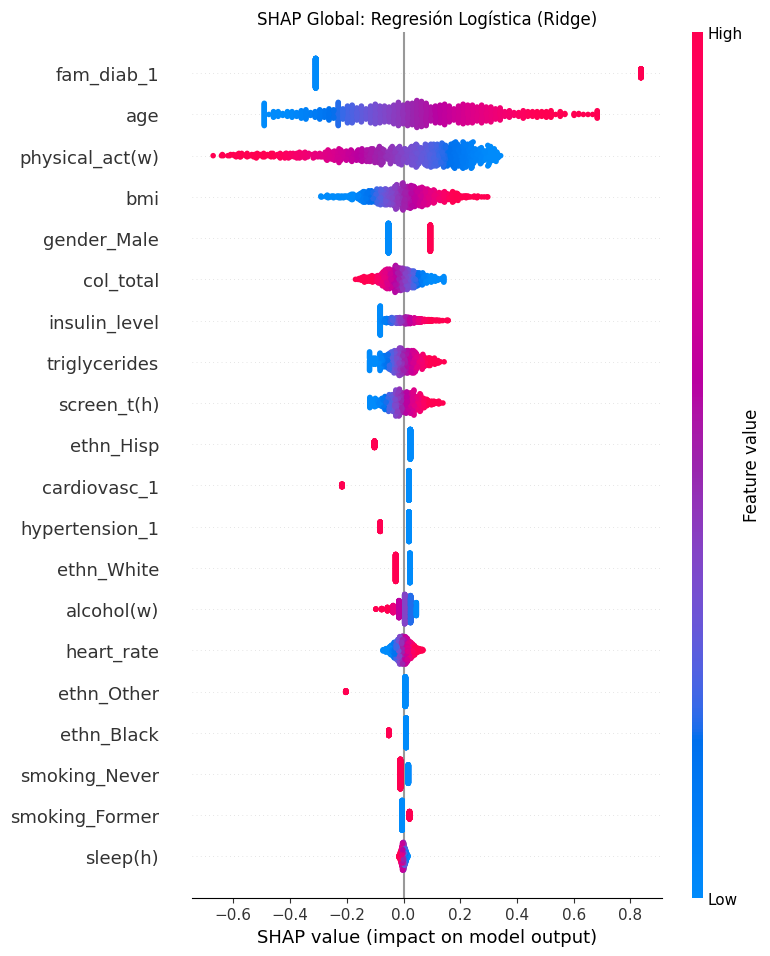

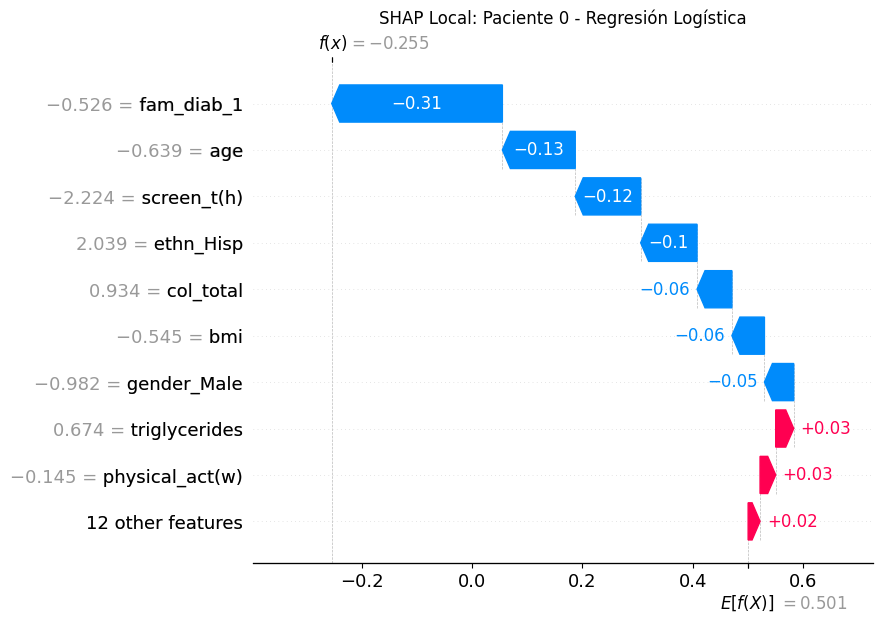

In [ ]:
# Inicializar el entorno gráfico de SHAP
shap.initjs()

# ==========================================
# A. Regresión Logística y Ridge (Linear Explainer)
# ==========================================
print("--- SHAP para Regresión Logística (Ridge) ---")
explainer_log = shap.LinearExplainer(ridge_cv, X_train_scaled_df)
shap_values_log = explainer_log(X_test_scaled_df)

# Gráfico Global (Importancia de variables)
plt.figure()
shap.summary_plot(shap_values_log, X_test_scaled_df, show=False)
plt.title("SHAP Global: Regresión Logística (Ridge)")
plt.show()

# Gráfico Local (Explicación del paciente seleccionado)
plt.figure()
shap.plots.waterfall(shap_values_log[indice_paciente], show=False)
plt.title(f"SHAP Local: Paciente {indice_paciente} - Regresión Logística")
plt.show()

In [ ]:
print("--- Configurando LIME Explainer ---")

# Inicializamos el explicador tabular de LIME
explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_scaled_df),
    feature_names=columnas,
    class_names=['No Diabético', 'Diabético'],
    mode='classification',
    random_state=42
)

# ==========================================
# A. LIME para Regresión Logística (Ridge)
# ==========================================
print("\nExplicación LIME - Regresión Logística:")
exp_log = explainer_lime.explain_instance(
    data_row=paciente_ejemplo,
    predict_fn=ridge_cv.predict_proba,
    num_features=6
)
exp_log.show_in_notebook(show_table=True)

--- Configurando LIME Explainer ---

Explicación LIME - Regresión Logística:


/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.